# Análisis Ley de Torricelli en base a la salida en el paso 15

Ubicamos las partículas más altas y más a la derecha para determinar la altura del fluido y las primeras partículas que salen por el agujero del lado derecho.

In [42]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from Config.utils.plot_ics import plot_ics

PATH_OUTPUT_TORRICELLI = PROJECT_ROOT / "Output" / "Torricelli"

PATH_OUTPUT_VACIADO = PATH_OUTPUT_TORRICELLI / "Funcional_Torricelli_40x40" / "vaciado_caida4k" / "Output"
PATH_OUTPUT_F_ESTAB = PATH_OUTPUT_TORRICELLI / "Funcional_Torricelli_40x40" / "vaciado_estabilizacion4k" / "Output"

FILE_OUTPUT_1000 = PATH_OUTPUT_VACIADO / "state_1000.txt"
ESTAB_OUTPUT_FSTEP = PATH_OUTPUT_F_ESTAB / "state_3999.txt"

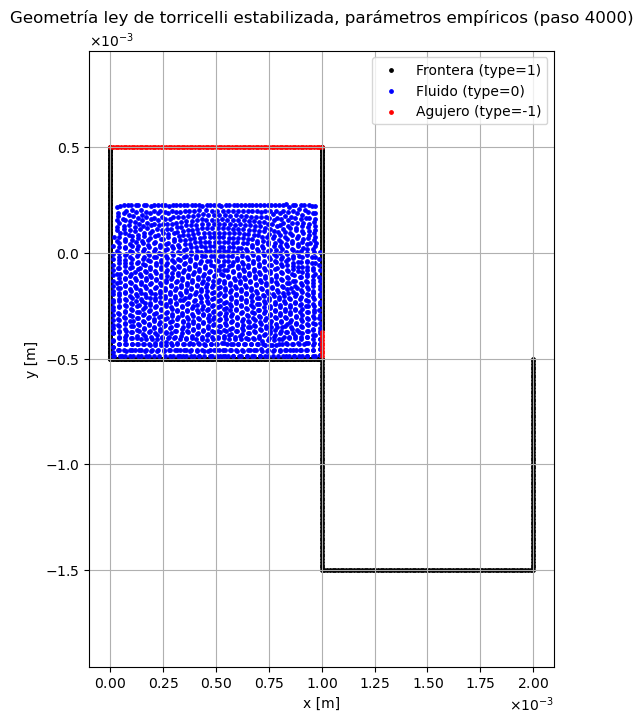

In [53]:
plot_ics(ESTAB_OUTPUT_FSTEP, "Geometría ley de torricelli estabilizada, parámetros empíricos (paso 4000)")

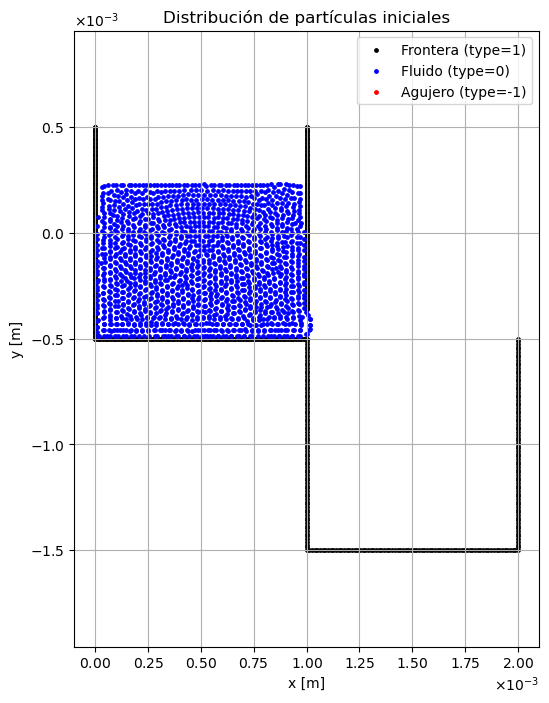

In [2]:
FILE_OUTPUT_0015 = PATH_OUTPUT_VACIADO / "state_0015.txt"

plot_ics(FILE_OUTPUT_0015)

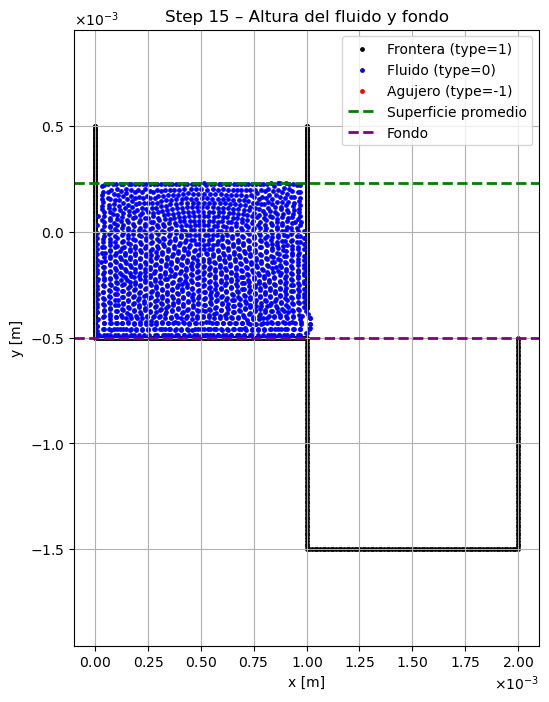

Altura de la superficie libre respecto al fondo 7.28751e-04
Posición de la superficie libre en y 2.28751e-04


In [40]:
from Analysis.utils.torricelli_calculus import analizar_altura_fluido

resultado_15 = analizar_altura_fluido(
    FILE_OUTPUT_0015,
    delta_rel=0.01,
    title="Step 15 – Altura del fluido y fondo"
)

y_sup_libre = resultado_15['y_sup_prom']
H = resultado_15['altura_fluido']
print(f"Altura de la superficie libre respecto al fondo {H:.5e}")
print(f"Posición de la superficie libre en y {y_sup_libre:.5e}")


In [4]:
import pandas as pd

x_hole = 1e-3
h = 2.75e-5

df_step_15 = pd.read_csv(str(FILE_OUTPUT_0015), sep='\s+')
df_step_15.head(5)

,id,posx,posy,velx,vely,accelx,accely,rho,mass,pressure,h,internalE,type
0,0,0.0,0.000500,0.0,0.0,0.0,0.0,1000.0,6.250000e-07,0.0,0.000028,0.0,1
1,1,0.0,0.000487,0.0,0.0,0.0,0.0,1000.0,6.250000e-07,0.0,0.000028,0.0,1
2,2,0.0,0.000475,0.0,0.0,0.0,0.0,1000.0,6.250000e-07,0.0,0.000028,0.0,1
3,3,0.0,0.000463,0.0,0.0,0.0,0.0,1000.0,6.250000e-07,0.0,0.000028,0.0,1
4,4,0.0,0.000450,0.0,0.0,0.0,0.0,1000.0,6.250000e-07,0.0,0.000028,0.0,1


In [5]:
df_salida_step15 = df_step_15[
    (df_step_15["type"] == 0) &
    (df_step_15["posx"] >= x_hole) &
    (df_step_15["posx"] <= x_hole + 2*h)
]

df_salida_step15.head(10)

,id,posx,posy,velx,vely,accelx,accely,rho,mass,pressure,h,internalE,type
738,829,0.001004,-0.000478,0.023136,0.002525,68.220510,12.236896,1347.467109,6.250000e-07,3.391404,0.000028,0.000810,0
818,909,0.001014,-0.000457,0.045162,-0.003404,49.974686,-20.338002,1306.487891,6.250000e-07,2.638738,0.000028,0.001248,0
857,948,0.001014,-0.000457,0.043362,-0.003131,42.659152,-18.270767,1306.574552,6.250000e-07,2.640187,0.000028,0.001481,0
858,949,0.001017,-0.000434,0.048605,-0.003024,22.902079,3.177498,1289.261544,6.250000e-07,2.362029,0.000028,0.001680,0
897,988,0.001017,-0.000434,0.048365,-0.003038,22.008898,3.247883,1282.959265,6.250000e-07,2.266195,0.000028,0.001544,0
898,989,0.001018,-0.000409,0.049563,-0.004735,32.362319,16.743193,1233.836720,6.250000e-07,1.609513,0.000028,0.001424,0
937,1028,0.001018,-0.000409,0.049873,-0.004641,35.362160,17.467453,1241.167111,6.250000e-07,1.697976,0.000028,0.001162,0
977,1068,0.001008,-0.000390,0.031741,-0.010477,41.433673,-6.744721,1272.419756,6.250000e-07,2.112114,0.000028,0.000775,0


In [6]:
len(df_salida_step15["id"].values)

8

En la posicion 10 solo salieron 8 partículas, analizemos su comportamiento.

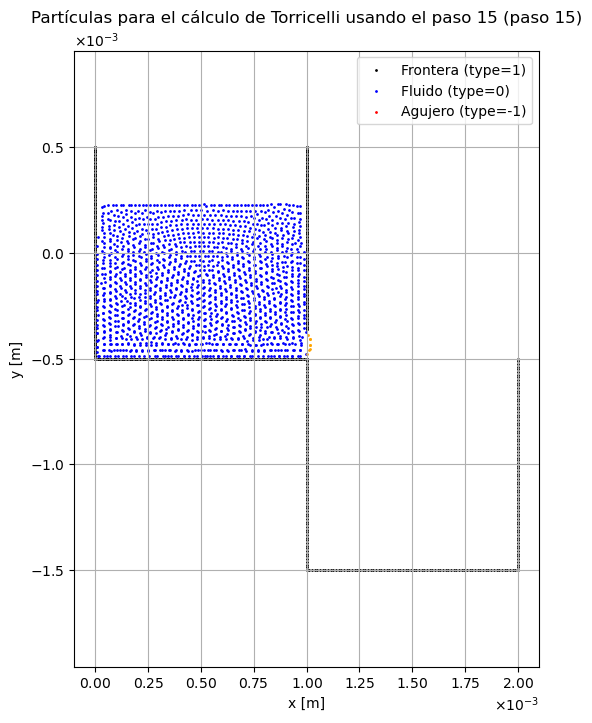

In [48]:
from Analysis.utils.plot_simulation_step import plot_step_resaltado

plot_step_resaltado(
    archivo_txt=FILE_OUTPUT_0015,
    df_resaltado=df_salida_step15,
    particle_size=1,
    title="Partículas para el cálculo de Torricelli usando el paso 15 (paso 15)"
)

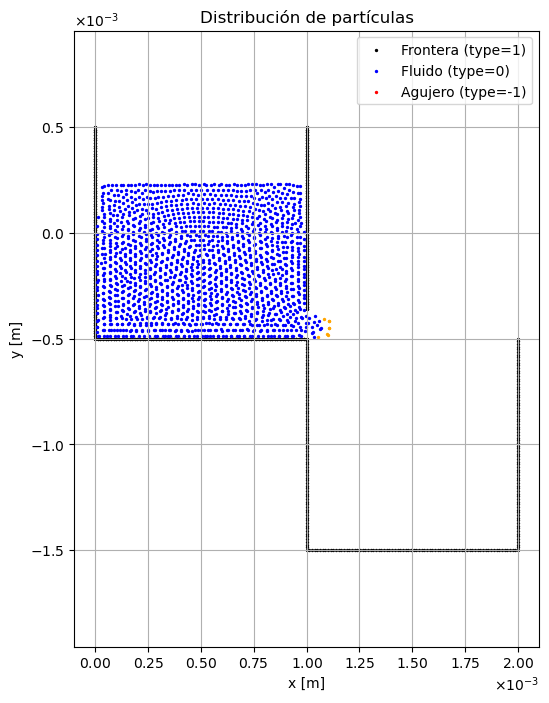

In [8]:
FILE_OUTPUT_0050 = PATH_OUTPUT_VACIADO / "state_0050.txt"

plot_step_resaltado(
    archivo_txt=FILE_OUTPUT_0050,
    df_resaltado=df_salida_step15,
    particle_size=2
)

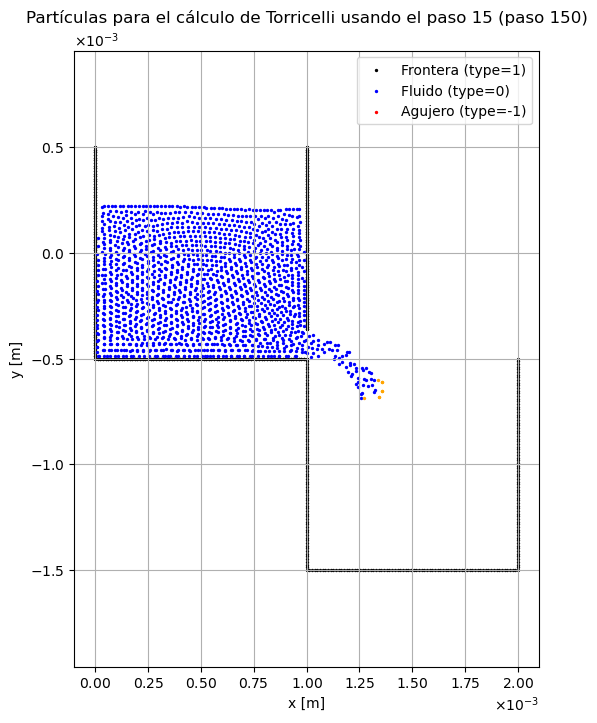

In [49]:
FILE_OUTPUT_0150 = PATH_OUTPUT_VACIADO / "state_0150.txt"

plot_step_resaltado(
    archivo_txt=FILE_OUTPUT_0150,
    df_resaltado=df_salida_step15,
    particle_size=2,
    title="Partículas para el cálculo de Torricelli usando el paso 15 (paso 150)"
)

In [10]:
from Analysis.utils.torricelli_calculus import extraer_trayectorias_particulas

trayectorias = extraer_trayectorias_particulas(
    path_states=f"{PATH_OUTPUT_VACIADO}",
    df_particulas_inicial=df_salida_step15
)

In [13]:
trayectorias.head(16)

,id,posx,posy,step
0,829,0.000989,-0.000481,0
1,909,0.000989,-0.000456,0
2,948,0.000989,-0.000456,0
3,949,0.000989,-0.000431,0
4,988,0.000989,-0.000431,0
5,989,0.000989,-0.000406,0
6,1028,0.000989,-0.000406,0
7,1068,0.000989,-0.000381,0
8,829,0.000990,-0.000481,1
9,909,0.000990,-0.000456,1


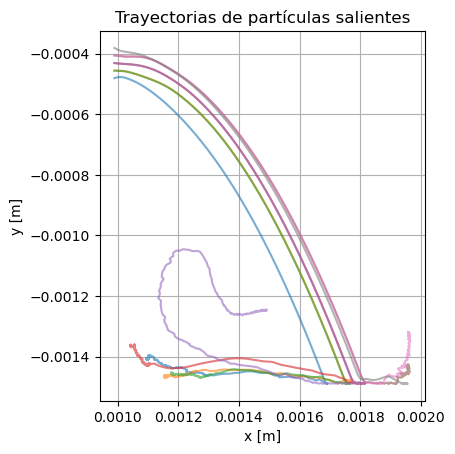

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for pid, df_p in trayectorias.groupby("id"):
    ax.plot(df_p["posx"], df_p["posy"], alpha=0.6)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Trayectorias de partículas salientes")
ax.set_aspect("equal")
ax.grid(True)

plt.show()

In [28]:
import numpy as np
import pandas as pd

def cortar_trayectorias_por_id(
    df_trayectorias,
    tol=1e-7,
    min_steps=100
):
    """
    Corta cada trayectoria cuando y deja de decrecer
    (primer mínimo físico), procesando id por id.

    Parámetros
    ----------
    df_trayectorias : DataFrame
        Columnas: step, id, posx, posy
    tol : float
        Tolerancia para ignorar ruido numérico
    min_steps : int
        Mínimo de puntos antes de permitir el corte

    Retorna
    -------
    DataFrame
        Trayectorias cortadas id por id
    """

    trayectorias_cortadas = []

    for pid, df_p in df_trayectorias.groupby("id"):
        df_p = df_p.sort_values("step").reset_index(drop=True)

        y = df_p["posy"].values
        dy = np.diff(y)

        corte_idx = None

        for i in range(min_steps - 1, len(dy)):
            if dy[i] > tol:
                corte_idx = i + 1
                break

        if corte_idx is None:
            trayectorias_cortadas.append(df_p)
        else:
            trayectorias_cortadas.append(df_p.iloc[:corte_idx + 1])

    return pd.concat(trayectorias_cortadas, ignore_index=True)

In [29]:
trayectorias_cortadas = cortar_trayectorias_por_id(trayectorias)

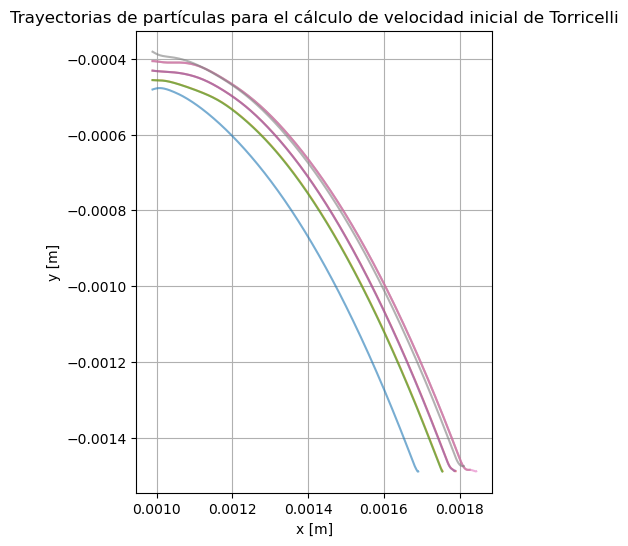

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

for pid, df_p in trayectorias_cortadas.groupby("id"):
    ax.plot(df_p["posx"], df_p["posy"], alpha=0.6)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Trayectorias de partículas para el cálculo de velocidad inicial de Torricelli")
ax.set_aspect("equal")
ax.grid(True)

plt.show()

In [55]:
import numpy as np
from numpy.linalg import lstsq

def ajustar_trayectoria_con_g(
    df_trayectoria,
    dt=5e-5,
    g=9.8
):
    """
    Ajusta una trayectoria a movimiento balístico
    con gravedad conocida.

    Retorna velocidades iniciales en m/s.
    """

    # Tiempo relativo (s)
    t = (df_trayectoria["step"].values
         - df_trayectoria["step"].iloc[0]) * dt

    x = df_trayectoria["posx"].values
    y = df_trayectoria["posy"].values

    # x(t) = x0 + vx0 t
    A_x = np.column_stack([np.ones_like(t), t])
    x0, vx0 = lstsq(A_x, x, rcond=None)[0]

    # y(t) = y0 + vy0 t - 0.5 g t^2
    A_y = np.column_stack([np.ones_like(t), t])
    b_y = y + 0.5 * g * t**2
    y0, vy0 = lstsq(A_y, b_y, rcond=None)[0]

    return {
        "vx0": vx0,
        "vy0": vy0
    }

In [56]:
def ajustar_trayectoria_sin_g(
    df_trayectoria,
    dt=5e-5
):
    """
    Ajusta una trayectoria sin asumir gravedad conocida.
    Infiere la aceleración efectiva.

    Retorna velocidades iniciales y g inferida.
    """

    # Tiempo relativo (s)
    t = (df_trayectoria["step"].values
         - df_trayectoria["step"].iloc[0]) * dt

    x = df_trayectoria["posx"].values
    y = df_trayectoria["posy"].values

    # x(t) = x0 + vx0 t
    A_x = np.column_stack([np.ones_like(t), t])
    x0, vx0 = lstsq(A_x, x, rcond=None)[0]

    # y(t) = y0 + vy0 t + 0.5 a t^2
    A_y = np.column_stack([np.ones_like(t), t, t**2])
    y0, vy0, a = lstsq(A_y, y, rcond=None)[0]

    g_fit = -2 * a

    return {
        "vx0": vx0,
        "vy0": vy0,
        "g_fit": g_fit
    }


In [57]:
resultados_con_g = []

for pid, df_p in trayectorias_cortadas.groupby("id"):
    if len(df_p) < 5:
        continue  # no suficientes puntos

    res = ajustar_trayectoria_con_g(
        df_p,
        dt=5e-5,
        g=9.81
    )

    resultados_con_g.append({
        "id": pid,
        **res
    })

df_vel_con_g = pd.DataFrame(resultados_con_g)

In [58]:
print(df_vel_con_g)

     id       vx0       vy0
0   829  0.047044  0.011661
1   909  0.049583  0.010861
2   948  0.049642  0.010840
3   949  0.050319  0.010974
4   988  0.050266  0.011013
5   989  0.051861  0.012268
6  1028  0.051820  0.013344
7  1068  0.052008  0.012000


In [59]:
resultados_sin_g = []

for pid, df_p in trayectorias_cortadas.groupby("id"):
    if len(df_p) < 5:
        continue

    res = ajustar_trayectoria_sin_g(
        df_p,
        dt=5e-5
    )

    resultados_sin_g.append({
        "id": pid,
        **res
    })

df_vel_sin_g = pd.DataFrame(resultados_sin_g)

In [60]:
print(df_vel_sin_g)

     id       vx0       vy0     g_fit
0   829  0.047044  0.007688  9.305427
1   909  0.049583  0.004448  8.998255
2   948  0.049642  0.004418  8.997077
3   949  0.050319  0.004025  8.949406
4   988  0.050266  0.004056  8.948462
5   989  0.051861  0.007640  9.245637
6  1028  0.051820  0.004067  8.715340
7  1068  0.052008  0.006569  9.143690


In [61]:
df_vel_con_g["vx0"].mean()

np.float64(0.0503178407351053)

In [63]:
df_vel_con_g["vy0"].mean()

np.float64(0.011620125264116807)

In [64]:
df_vel_sin_g["vx0"].mean()

np.float64(0.0503178407351053)

In [65]:
df_vel_sin_g["vy0"].mean()

np.float64(0.005363867555829634)

In [62]:
df_vel_sin_g["g_fit"].mean()

np.float64(9.037911603297463)

Altura de la superficie libre respecto al fondo 7.28477e-04

In [32]:
# Verificamos la cuenta usando la ley de Torricelli

v0 = np.sqrt(2*9.8*7.285e-4)
print(v0)

0.1194930960348756


Usaremos el paso 10 para que halla el tiempo suficiente en que algunas pocas partículas pasen el agujero

In [10]:
import numpy as np

file = str(step10fall)   # Cambiar por el archivo que quieras

data = np.loadtxt(file, skiprows=1)

# Columnas según tu formato
ids   = data[:,0]
posx  = data[:,1]
posy  = data[:,2]
types = data[:,12]

# Filtrar solo las partículas de interés: type = 0
mask = types == 0

ids_0  = ids[mask]
posx_0 = posx[mask]
posy_0 = posy[mask]

# Partícula más alta
i_max_y = np.argmax(posy_0)
id_max_y = ids_0[i_max_y]
height   = posy_0[i_max_y]

# Partícula más a la derecha
i_max_x  = np.argmax(posx_0)
id_max_x = ids_0[i_max_x]
rightmost = posx_0[i_max_x]

print(f"Partícula más alta: id={id_max_y}, altura={height}")
print(f"Partícula más a la derecha: id={id_max_x}, posx={rightmost}")


Partícula más alta: id=2387.0, altura=0.0002296475
Partícula más a la derecha: id=1028.0, posx=0.0010064304


In [11]:
from utils.upRightPos import find_part_up_right

file = step10fall
n_up = 15
n_right = 5

up_part, right_part = find_part_up_right(file, n_up, n_right)

print("Altas:", up_part)
print("Más a la derecha:", right_part)

Altas: {2387: 0.0002296475, 2388: 0.0002288241, 2371: 0.0002285679, 2389: 0.0002285123, 2348: 0.000228485, 2349: 0.0002281488, 2367: 0.000227828, 2386: 0.0002278003, 2357: 0.0002271995, 2372: 0.0002271828, 2381: 0.0002271598, 2369: 0.0002269887, 2383: 0.0002269839, 2368: 0.0002269162, 2382: 0.000226796}
Más a la derecha: {1028: 0.0010064304, 989: 0.0010061842, 949: 0.0010050429, 988: 0.0010050291, 909: 0.0010036757}


Promedio de altura de fluido y de partículas más a la derecha

In [12]:
import numpy as np

up_mean = np.mean(list(up_part.values()))
right_mean = np.mean(list(right_part.values()))

print("Promedio de alturas:", up_mean)
print("Promedio de posiciones derechas:", right_mean)


Promedio de alturas: 0.00022780272
Promedio de posiciones derechas: 0.0010052724599999999


In [13]:
h = up_mean
g = 9.8

torri_law = np.sqrt(2*g*h)
print(torri_law)

0.06682015647991256


In [14]:
import numpy as np
import glob
import re
from pathlib import Path

def track_particle(folder, particle_id):
    """
    Lee todos los archivos state_*.txt dentro de 'folder'
    y rastrea la posición y velocidad de una partícula dada por su id.
    """

    folder = Path(folder)

    # Buscar archivos que coincidan con state_*.txt
    files = list(folder.glob("state_*.txt"))

    # Ordenar por el número dentro del nombre state_XXXX.txt
    def extract_num(fname):
        match = re.search(r"state_(\d+)\.txt", fname.name)
        return int(match.group(1)) if match else -1

    files = sorted(files, key=extract_num)

    # Listas donde se acumula la trayectoria
    times = []
    posx_list = []
    posy_list = []
    velx_list = []
    vely_list = []

    for f in files:
        step = extract_num(f)
        
        # Cargar archivo (saltando encabezado)
        data = np.loadtxt(f, skiprows=1)

        ids   = data[:,0]
        posx  = data[:,1]
        posy  = data[:,2]
        velx  = data[:,3]
        vely  = data[:,4]

        # Buscar índice donde id == particle_id
        match = np.where(ids == particle_id)[0]

        if len(match) == 0:
            print(f"⚠ Advertencia: Partícula {particle_id} no aparece en {f.name}")
            continue

        idx = match[0]

        times.append(step)
        posx_list.append(posx[idx])
        posy_list.append(posy[idx])
        velx_list.append(velx[idx])
        vely_list.append(vely[idx])

    return {
        "time_steps": np.array(times),
        "posx": np.array(posx_list),
        "posy": np.array(posy_list),
        "velx": np.array(velx_list),
        "vely": np.array(vely_list),
    }

In [15]:
# Rastrear la partícula
folder = PROJECT_ROOT / "Output" / "vaciado_caida4k" / "Output"
particle_id = 1028     # cámbiala por la partícula que quieras seguir

traj_1028 = track_particle(folder, particle_id)

In [16]:
import matplotlib.pyplot as plt
# Se debe multiplicar el valor de tiempo por el dt para pasar a segundos

dt = 5e-5

t_1028 = traj_1028["time_steps"] * dt
x_1028 = traj_1028["posx"]
y_1028 = traj_1028["posy"]

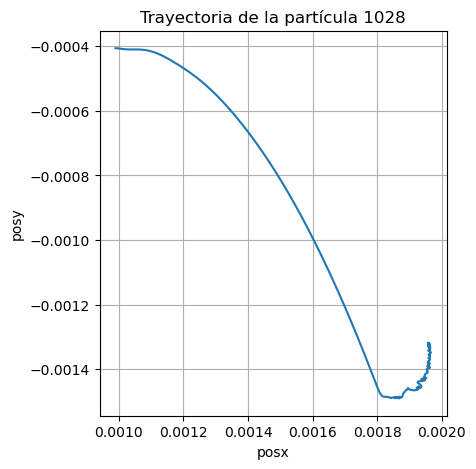

In [17]:
import matplotlib.pyplot as plt

# --- Gráfico de la trayectoria en 2D ---
plt.figure(figsize=(6,5))
plt.plot(x_1028, y_1028)
plt.xlabel("posx")
plt.ylabel("posy")
plt.title(f"Trayectoria de la partícula {particle_id}")
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Es necesario determinar el lugar en el que la partícula rebota en el fondo del nuevo recipiente

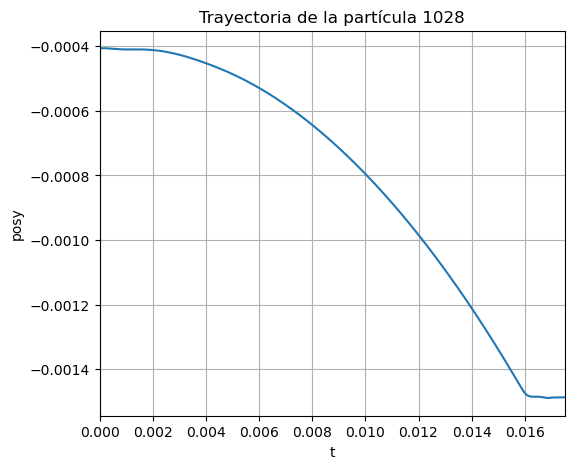

In [18]:
import matplotlib.pyplot as plt

# --- Gráfico de la trayectoria en 2D ---
plt.figure(figsize=(6,5))
plt.plot(t_1028, y_1028)
plt.xlabel("t")
plt.ylabel("posy")
plt.title(f"Trayectoria de la partícula {particle_id}")
plt.xlim(0, 0.0175)
plt.grid(True)
#plt.gca().set_aspect('equal', adjustable='box')
plt.show()

La caída de la partícula 1028 parece darse hasta cerca de un tiempo de 0.016s, calculamos el paso en el que esto ocurrre:

In [19]:
fall_step = 0.016 / 5e-5
print("Paso aproximado en la que la primera partícula rebota:", fall_step)

Paso aproximado en la que la primera partícula rebota: 320.0


In [20]:
import numpy as np

# Extraer vectores
steps = np.asarray(traj_1028["time_steps"])
x = np.asarray(traj_1028["posx"])
y = np.asarray(traj_1028["posy"])

x_par = [x[i] for i in range(int(fall_step))]
y_par = [y[i] for i in range(int(fall_step))]
t_par = [steps[i]*dt for i in range(int(fall_step))]

In [21]:
# Ajustamos a un polinomio de grado 2: y = at^2 + bt + c

coef = np.polyfit(t_par, y_par, 2)

a, b, c = coef
g = 2*a
print(a,b,c)
print("Aceleración gravitacional:", g)

-4.679279662003979 0.008338964227895283 -0.0004106178594747342
Aceleración gravitacional: -9.358559324007958


In [22]:
traj_1028.items()

dict_items([('time_steps', array([    0,     1,     2, ..., 11997, 11998, 11999])), ('posx', array([0.0009895 , 0.00099014, 0.00099116, ..., 0.00196159, 0.00196159,
       0.00196159])), ('posy', array([-0.0004062 , -0.00040619, -0.00040621, ..., -0.0013344 ,
       -0.0013344 , -0.00133441])), ('velx', array([8.92610160e-03, 1.69138104e-02, 2.37169472e-02, ...,
       4.07260000e-06, 4.07880000e-06, 4.07000000e-06])), ('vely', array([ 1.745266e-04,  1.790670e-05, -5.000661e-04, ..., -6.404450e-05,
       -6.419620e-05, -6.431180e-05]))])

In [23]:
print("El valor de la velocidad inicial según Torricelli es", torri_law)

El valor de la velocidad inicial según Torricelli es 0.06682015647991256


Para ver si en la simulación concuerda hacemos uso de graficar la velocidad en x vs. el tiempo, la velocidad debe hacerse constante en algún punto ya que no hay aceleración en x.

In [24]:
vel_x1028 = traj_1028["velx"]
print(vel_x1028)

[8.92610160e-03 1.69138104e-02 2.37169472e-02 ... 4.07260000e-06
 4.07880000e-06 4.07000000e-06]


(0.0, 0.02)

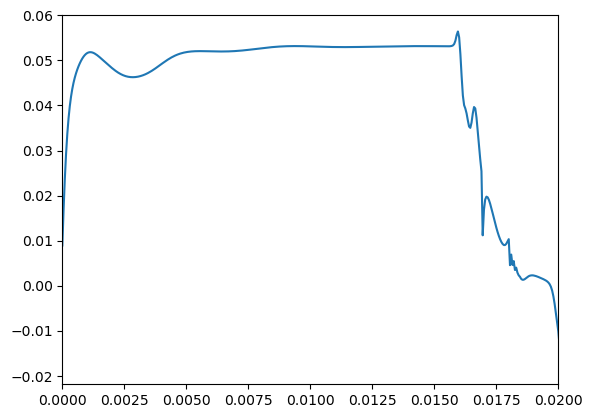

In [25]:
plt.plot(t_1028, vel_x1028)
plt.xlim(0,400*dt)

Vemos que el valor luego de la interacción con frontera se estabiliza alrededor de 0.05 m/s, mientras que según la ley de Torricelli esta debería estar alrededor de 0.07 m/s.

In [26]:
# Velocidad inicial en y calculada con el ajuste

print("Velocidad inicial en y ajuste:", b)

Velocidad inicial en y ajuste: 0.008338964227895283


In [2]:
import numpy as np

h = 0.00022780272
g=9.35

torri_law2 = np.sqrt(2*g*h)

print(torri_law2)

0.06526799264570651
